# 04 — Model Validation & Comparison

Sensitivity analysis, supervised benchmarks (Ridge, ElasticNet, RF, KNN, Gradient Boosting), and final comparison.

In [1]:
import notebook_lib as nb
import pandas as pd

nb.setup_path()
df = nb.load_and_score()
base_mean = df['final_score'].mean()
print(f'Portfolio: {len(df)} | mean score {base_mean:.2f}')
print(df['risk_band'].value_counts())

Portfolio: 500 | mean score 38.87
risk_band
Medium    436
High       48
Low        16
Name: count, dtype: int64


## 1. Sensitivity

,scenario,mean_score_delta
0,TIV +20%,0.568
1,Claims +20%,0.196
2,Wildfire +20%,0.009
3,Roof age +5yr,0.000


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\04_sensitivity.png


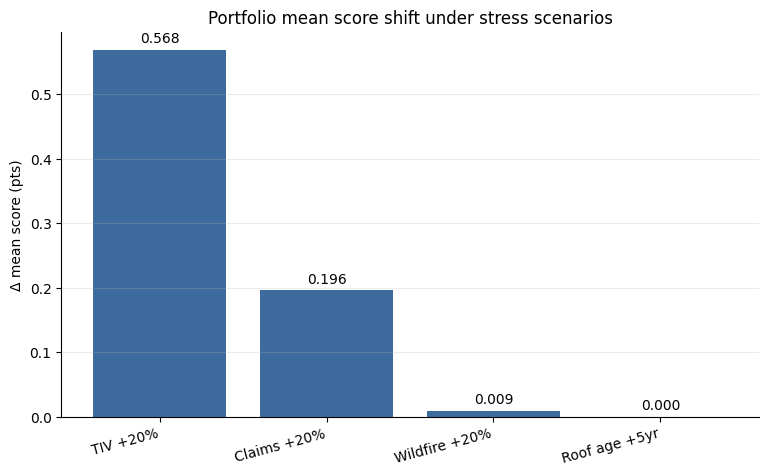

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/04_sensitivity.png')

In [2]:
def sensitivity(feature, factor=1.2):
    trial = df.copy()
    col = f'clean_{feature}'
    if col not in trial.columns:
        return float('nan')
    trial[col] = trial[col] * factor
    return nb.run_scoring(trial)['final_score'].mean() - base_mean

sensitivity_df = pd.DataFrame([
    {'scenario': 'TIV +20%', 'mean_score_delta': round(sensitivity('total_insured_value_amt'), 3)},
    {'scenario': 'Claims +20%', 'mean_score_delta': round(sensitivity('lifetime_claim_ct'), 3)},
    {'scenario': 'Wildfire +20%', 'mean_score_delta': round(sensitivity('wildfire_risk_score'), 3)},
    {'scenario': 'Roof age +5yr', 'mean_score_delta': round(sensitivity('roof_age_years', 1.0 + 5/30), 3)},
])
display(sensitivity_df)
nb.plot_sensitivity(sensitivity_df)

## 2. Model benchmarks (75/25 holdout)

Regression target = peer score with train-only percentiles. Classification = score ≥ 50.

In [3]:
reg_results, clf_results, meta = nb.run_model_comparison(df, test_size=0.25, random_state=42)
print(meta)
nb.save_report_artifact(reg_results, '04_regression_results.csv')
nb.save_report_artifact(clf_results, '04_classification_results.csv')

{'train_size': 375, 'test_size': 125, 'regression_target': 'Holdout peer-group score (0–100)', 'classification_target': 'high_priority if holdout score >= 50', 'claim_spearman_note': 'Rank alignment with lifetime_claim_ct on test set'}


WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/04_classification_results.csv')

## 3. Regression comparison

,model,family,mae,rmse,r2,spearman_claims
0,Peer-group (holdout),Reference,0.000,0.000,1.000,0.116
3,Random Forest,Regression,7.647,9.230,0.086,0.068
5,Gradient Boosting,Regression,7.900,9.714,-0.012,0.024
2,ElasticNet,Regression,7.953,9.859,-0.043,0.210
4,KNN (k=15),Regression,7.982,9.562,0.019,0.021
1,Ridge,Regression,7.984,9.942,-0.060,0.212


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\04_regression_mae.png


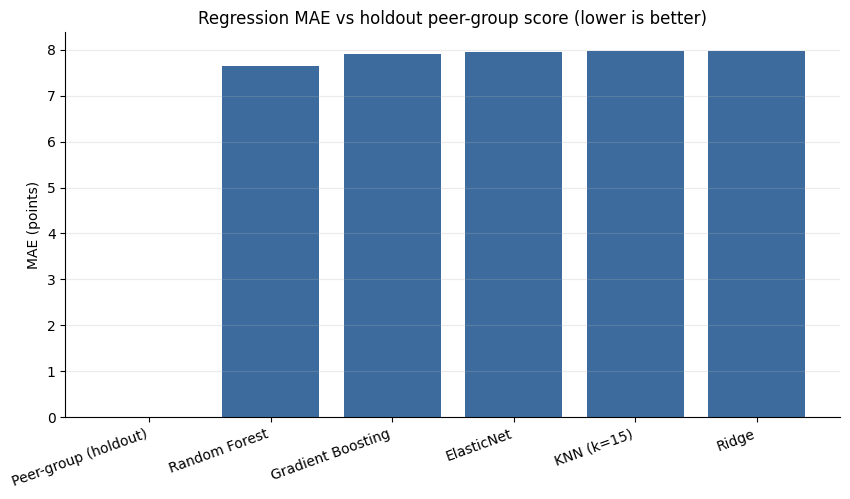

Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\04_regression_scatter.png


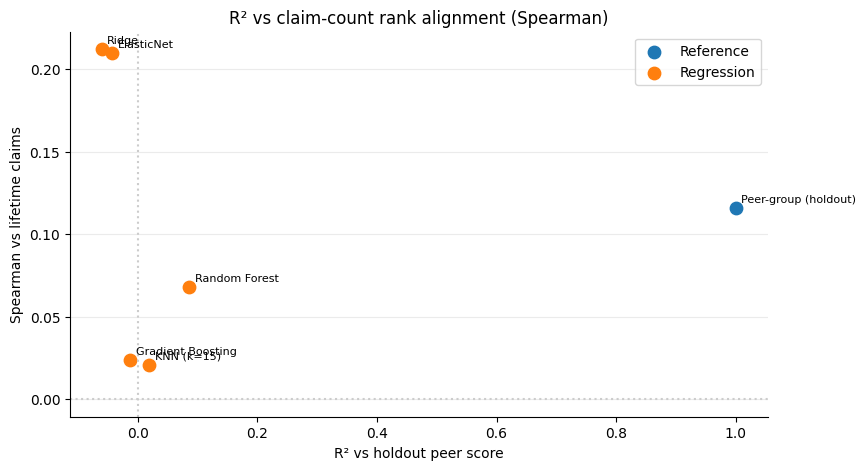

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/04_regression_scatter.png')

In [4]:
display(reg_results)
nb.plot_regression_mae(reg_results)
nb.plot_regression_scatter(reg_results)

## 4. Classification comparison

,model,family,accuracy,f1,auc
0,Peer-group (holdout),Reference,1.000,1.000,1.000
1,Logistic Regression,Classification,0.776,0.125,0.599
3,KNN (k=15),Classification,0.816,0.080,0.549
2,Random Forest,Classification,0.816,0.000,0.488


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\04_classification_auc.png


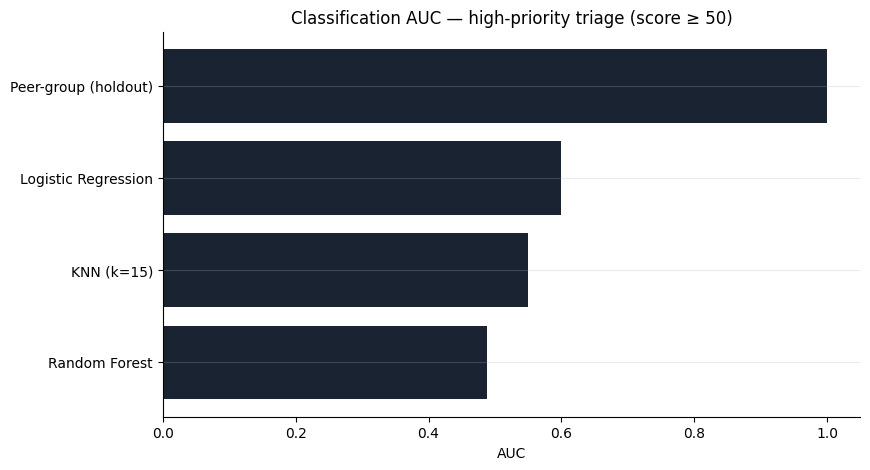

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/04_classification_auc.png')

In [5]:
display(clf_results)
nb.plot_classification_auc(clf_results)

## 5. Final comparison

,model,mae,r2,spearman_claims,accuracy,f1,auc
4,Peer-group (holdout),0.000,1.000,0.116,1.000,1.000,1.000
5,Random Forest,7.647,0.086,0.068,0.816,0.000,0.488
1,Gradient Boosting,7.900,-0.012,0.024,NaN,NaN,NaN
0,ElasticNet,7.953,-0.043,0.210,NaN,NaN,NaN
2,KNN (k=15),7.982,0.019,0.021,0.816,0.080,0.549
6,Ridge,7.984,-0.060,0.212,NaN,NaN,NaN
3,Logistic Regression,NaN,NaN,NaN,0.776,0.125,0.599


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\04_final_comparison.png


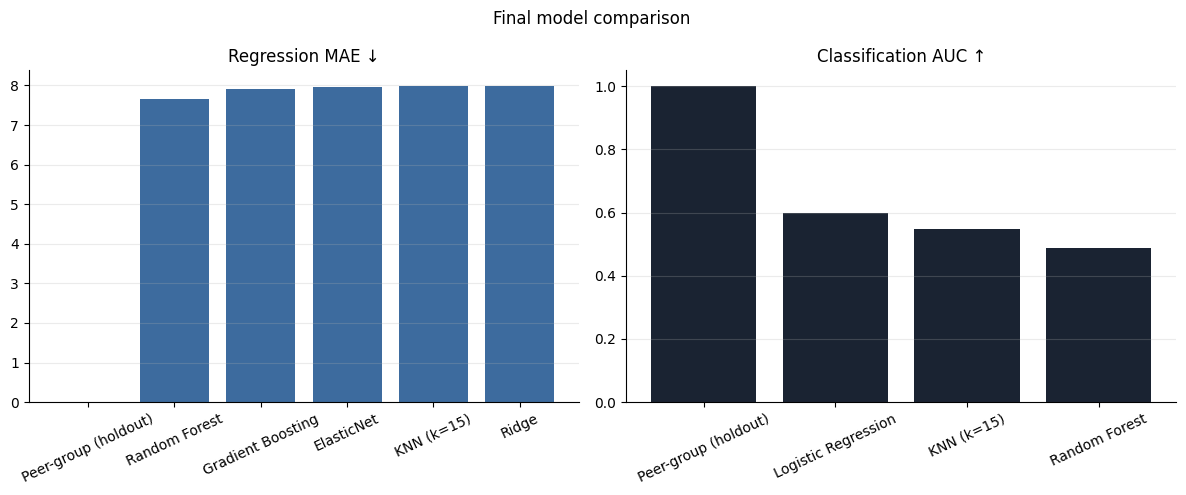

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/04_final_comparison.png')

In [6]:
summary = reg_results[['model', 'mae', 'r2', 'spearman_claims']].merge(
    clf_results[['model', 'accuracy', 'f1', 'auc']], on='model', how='outer'
)
display(summary.sort_values('mae'))
nb.save_report_artifact(summary, '04_final_comparison.csv')
nb.plot_final_comparison(summary)